Can we design better color cuts to separate ellipticals and spirals in the SGA?

In [2]:
from astropy.table import Table, join
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

import numpy as np

import os

import matplotlib.pyplot as plt

# SGA-2020

In [2]:
SGA = Table.read('/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits', 'ELLIPSE')
# SGA = Table.read('/Users/kdouglass/Documents/Research/data/SGA/SGA-2020.fits', 'ELLIPSE')

SGA[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

# Morphological classifications

In [3]:
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv'
# ai_morphpath = '../TF/Y1/'
ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'

# ai_morphcsv = os.path.join(ai_morphpath, 'sga10278_morphologies_model_analysis.csv')
# ai_morphcsv = os.path.join(ai_morphpath, 'TFY1_Classification.csv')
ai_morphcsv = os.path.join(ai_morphpath, 'final_classifications_SGA2020.csv')

ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab

SGA_ID,Classification
float64,str12
2.0,Spiral
3.0,Spiral
4.0,Irregular
7.0,Spiral
18.0,Elliptical
20.0,Irregular
24.0,Elliptical
25.0,Irregular
26.0,Elliptical


In [8]:
'''
# Create an overall record of the SSL prediction
ai_morphtab['Predicted_Type'] = 'Undecided '

for i in range(len(ai_morphtab)):
    
    classes = ai_morphtab['Spiral_Pred', 'Elliptical_Pred', 'Lenticular_Pred', 'Irregular_Pred'][i]
    
    ai_morphtab['Predicted_Type'][i] = next(j for j in classes if j != 'Other')
''';

In [4]:
# sgatab = join(SGA, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')
sgatab = join(SGA, ai_morphtab, keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
# sgatab['Predicted_Type'].name = 'MORPHTYPE_AI'
sgatab['Classification'].name = 'MORPHTYPE_AI'

In [5]:
elliptical = sgatab['MORPHTYPE_AI'] == 'Elliptical'

# Color-color plot

In [6]:
sgatab['g-r'] = sgatab['G_MAG_SB26'] - sgatab['R_MAG_SB26']
sgatab['r-z'] = sgatab['R_MAG_SB26'] - sgatab['Z_MAG_SB26']

In [7]:
cut1 = 1.3*np.array([-0.2, 1.1]) - 0.05
cut2 = 2.0*np.array([-0.2, 1.1]) - 0.15

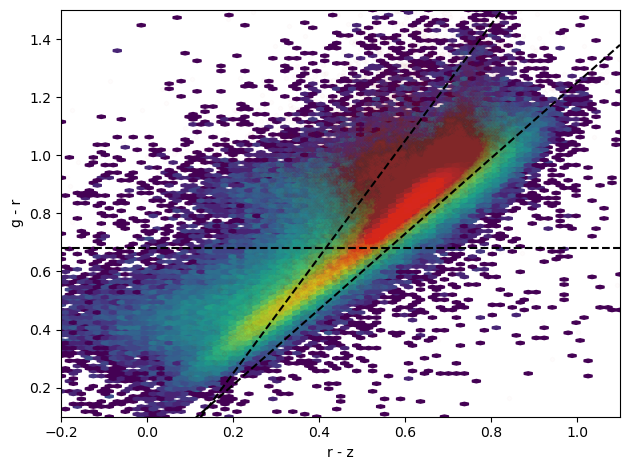

In [10]:
plt.figure(tight_layout=True)

plt.hexbin(sgatab['r-z'][~elliptical], sgatab['g-r'][~elliptical], 
           mincnt=1, 
           vmin=1, 
           vmax=1000, 
           gridsize=(70,80), 
           extent=(-0.2, 1.1, 0.1, 1.5), 
           bins='log')
plt.plot(sgatab['r-z'][elliptical], sgatab['g-r'][elliptical], '.', alpha=0.01, c='tab:red', label='Elliptical')

plt.hlines(0.68, -0.2, 1.1, colors='k', linestyles='dashed')
plt.plot([-0.2, 1.1], cut1, 'k--')
plt.plot([-0.2, 1.1], cut2, 'k--')

plt.xlim([-0.2, 1.1])
plt.ylim([0.1, 1.5])

plt.xlabel('r - z')
plt.ylabel('g - r');

While the elliptical galaxies do cluster in the region that the FP uses to define their sample, it looks like it's really more of just following the same underlying distribution as the full SGA-2020.

# SGA-2025

In [3]:
sga2025_directory = '/global/cfs/cdirs/cosmo/www/sga/2025/'

sga2025_filename = sga2025_directory + 'SGA2025-v1.0.fits'

hdul = fits.open(sga2025_filename)
SGA2025 = Table(hdul['SGA2025'].data)
ellipse_phot = hdul['ELLIPSEPHOT'].data
tractor_sga = hdul['TRACTOR'].data
hdul.close()

In [4]:
tractor_sga.names

['SGAID',
 'LS_ID_DR11',
 'RELEASE',
 'BRICKID',
 'BRICKNAME',
 'OBJID',
 'BRICK_PRIMARY',
 'MASKBITS',
 'FITBITS',
 'TYPE',
 'RA',
 'DEC',
 'RA_IVAR',
 'DEC_IVAR',
 'BX',
 'BY',
 'DCHISQ',
 'EBV',
 'MJD_MIN',
 'MJD_MAX',
 'NEAREST_NEIGHBOR',
 'REF_CAT',
 'REF_ID',
 'PMRA',
 'PMDEC',
 'PARALLAX',
 'PMRA_IVAR',
 'PMDEC_IVAR',
 'PARALLAX_IVAR',
 'REF_EPOCH',
 'GAIA_PHOT_G_MEAN_MAG',
 'GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR',
 'GAIA_PHOT_G_N_OBS',
 'GAIA_PHOT_BP_MEAN_MAG',
 'GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR',
 'GAIA_PHOT_BP_N_OBS',
 'GAIA_PHOT_RP_MEAN_MAG',
 'GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR',
 'GAIA_PHOT_RP_N_OBS',
 'GAIA_PHOT_VARIABLE_FLAG',
 'GAIA_ASTROMETRIC_EXCESS_NOISE',
 'GAIA_ASTROMETRIC_EXCESS_NOISE_SIG',
 'GAIA_ASTROMETRIC_N_OBS_AL',
 'GAIA_ASTROMETRIC_N_GOOD_OBS_AL',
 'GAIA_ASTROMETRIC_WEIGHT_AL',
 'GAIA_DUPLICATED_SOURCE',
 'GAIA_A_G_VAL',
 'GAIA_E_BP_MIN_RP_VAL',
 'GAIA_PHOT_BP_RP_EXCESS_FACTOR',
 'GAIA_ASTROMETRIC_SIGMA5D_MAX',
 'GAIA_ASTROMETRIC_PARAMS_SOLVED',
 'FLUX_G',
 'FLU

In [65]:
SGA2025['GINI_G'] = ellipse_phot['GINI_G']
SGA2025['GINI_R'] = ellipse_phot['GINI_R']
SGA2025['GINI_Z'] = ellipse_phot['GINI_Z']

SGA2025['COG_LNALPHA1_G'] = ellipse_phot['COG_LNALPHA1_G']
SGA2025['COG_LNALPHA1_R'] = ellipse_phot['COG_LNALPHA1_R']
SGA2025['COG_LNALPHA1_Z'] = ellipse_phot['COG_LNALPHA1_Z']

SGA2025['COG_LNALPHA2_G'] = ellipse_phot['COG_LNALPHA2_G']
SGA2025['COG_LNALPHA2_R'] = ellipse_phot['COG_LNALPHA2_R']
SGA2025['COG_LNALPHA2_Z'] = ellipse_phot['COG_LNALPHA2_Z']

SGA2025['COG_MTOT_G'] = ellipse_phot['COG_MTOT_G']
SGA2025['COG_MTOT_R'] = ellipse_phot['COG_MTOT_R']
SGA2025['COG_MTOT_Z'] = ellipse_phot['COG_MTOT_Z']

## Cross-match to SGA-2020

In [37]:
SGA2025_centers = SkyCoord(SGA2025['RA']*u.deg, SGA2025['DEC']*u.deg)
SGA2020_centers = SkyCoord(sgatab['RA']*u.deg, sgatab['DEC']*u.deg)

idx, d2d,_ = SGA2025_centers.match_to_catalog_sky(SGA2020_centers)

In [38]:
# print(len(SGA), len(SGA2025), len(idx))

SGA2025['SGA2020_ID'] = -1*np.ones(len(SGA2025), dtype=int)

SGA2025['SGA2020_ID'][d2d < 0.5*u.arcmin] = sgatab['SGA_ID'][idx[d2d < 0.5*u.arcmin]]

In [39]:
SGA2025 = join(SGA2025, sgatab['SGA_ID', 'MORPHTYPE_AI'], 
               keys_left='SGA2020_ID', keys_right='SGA_ID', 
               join_type='left')

In [40]:
elliptical_25 = SGA2025['MORPHTYPE_AI'] == 'Elliptical'

In [99]:
SGA2025['g-r'] = SGA2025['COG_MTOT_G'] - SGA2025['COG_MTOT_R']
SGA2025['r-z'] = SGA2025['COG_MTOT_R'] - SGA2025['COG_MTOT_Z']
SGA2025['g-z'] = SGA2025['COG_MTOT_G'] - SGA2025['COG_MTOT_Z']

# Gini coefficient

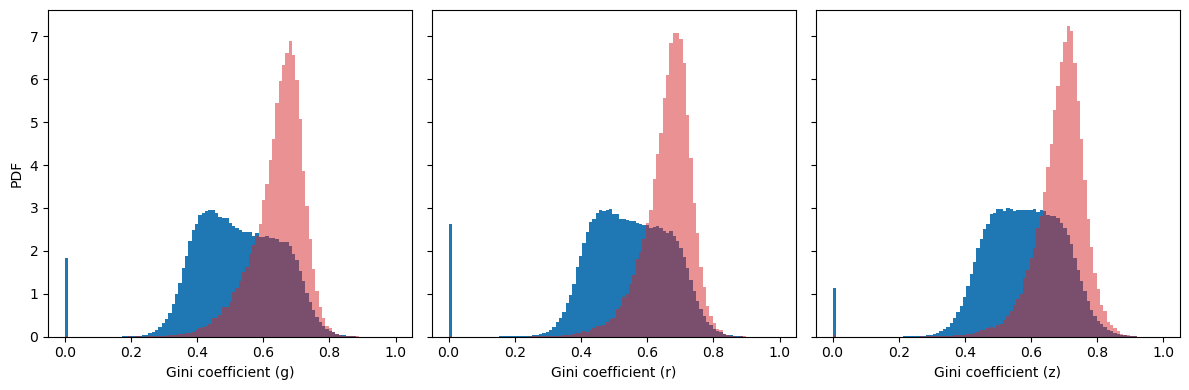

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(12,4), tight_layout=True, sharey=True)


axes[0].hist(SGA2025['GINI_G'][~elliptical_25], bins=np.linspace(0,1,100), color='tab:blue', density=True)
axes[0].hist(SGA2025['GINI_G'][elliptical_25], bins=np.linspace(0,1,100), color='tab:red', alpha=0.5, density=True)

axes[0].set(xlabel='Gini coefficient (g)', ylabel='PDF')


axes[1].hist(SGA2025['GINI_R'][~elliptical_25], bins=np.linspace(0,1,100), color='tab:blue', density=True)
axes[1].hist(SGA2025['GINI_R'][elliptical_25], bins=np.linspace(0,1,100), color='tab:red', alpha=0.5, density=True)

axes[1].set(xlabel='Gini coefficient (r)')


axes[2].hist(SGA2025['GINI_Z'][~elliptical_25], bins=np.linspace(0,1,100), color='tab:blue', density=True)
axes[2].hist(SGA2025['GINI_Z'][elliptical_25], bins=np.linspace(0,1,100), color='tab:red', alpha=0.5, density=True)

axes[2].set(xlabel='Gini coefficient (z)');

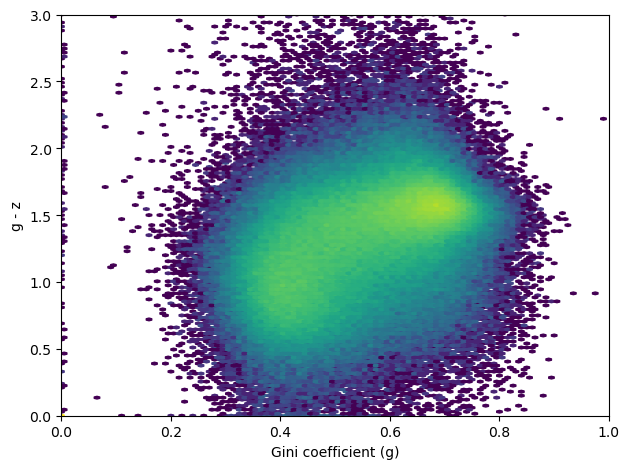

In [100]:
plt.figure(tight_layout=True)

plt.hexbin(SGA2025['GINI_G'][~elliptical_25], SGA2025['g-z'][~elliptical_25], 
           mincnt=1, 
           vmin=1, 
           vmax=1000, 
           gridsize=(100,100), 
           extent=(0, 1, 0, 3), 
           bins='log')

# plt.plot(SGA2025['GINI_G'][elliptical_25], SGA2025['COG_MTOT_G'][elliptical_25] - SGA2025['COG_MTOT_R'][elliptical_25], '.', alpha=0.01, c='tab:red')

plt.xlim(0,1)
plt.ylim(0,3)

plt.xlabel('Gini coefficient (g)')
plt.ylabel('g - z');

# Sersic parameters

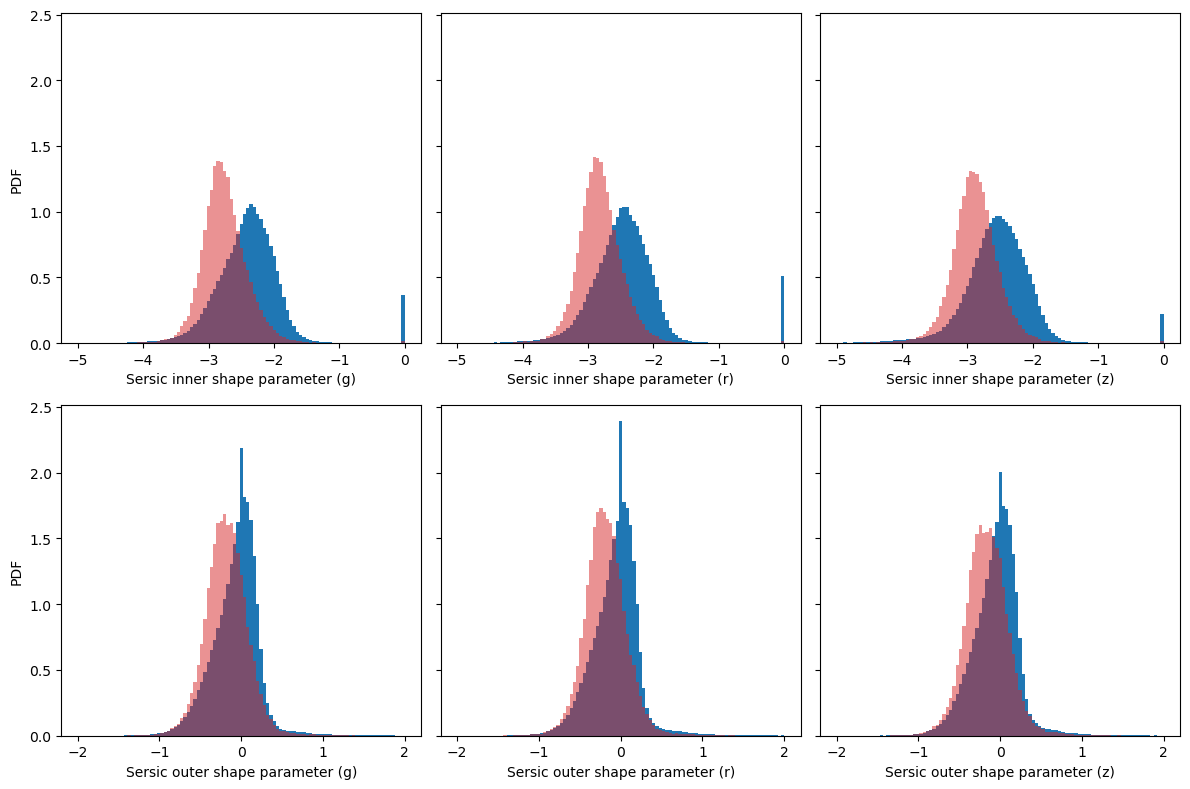

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(12,8), tight_layout=True, sharey=True)


axes[0,0].hist(SGA2025['COG_LNALPHA1_G'][~elliptical_25], bins=np.linspace(-5,0,100), color='tab:blue', density=True)
axes[0,0].hist(SGA2025['COG_LNALPHA1_G'][elliptical_25], bins=np.linspace(-5,0,100), color='tab:red', alpha=0.5, density=True)
axes[0,0].set(xlabel='Sersic inner shape parameter (g)', ylabel='PDF')

axes[0,1].hist(SGA2025['COG_LNALPHA1_R'][~elliptical_25], bins=np.linspace(-5,0,100), color='tab:blue', density=True)
axes[0,1].hist(SGA2025['COG_LNALPHA1_R'][elliptical_25], bins=np.linspace(-5,0,100), color='tab:red', alpha=0.5, density=True)
axes[0,1].set(xlabel='Sersic inner shape parameter (r)')

axes[0,2].hist(SGA2025['COG_LNALPHA1_Z'][~elliptical_25], bins=np.linspace(-5,0,100), color='tab:blue', density=True)
axes[0,2].hist(SGA2025['COG_LNALPHA1_Z'][elliptical_25], bins=np.linspace(-5,0,100), color='tab:red', alpha=0.5, density=True)
axes[0,2].set(xlabel='Sersic inner shape parameter (z)')


axes[1,0].hist(SGA2025['COG_LNALPHA2_G'][~elliptical_25], bins=np.linspace(-2,2,100), color='tab:blue', density=True)
axes[1,0].hist(SGA2025['COG_LNALPHA2_G'][elliptical_25], bins=np.linspace(-2,2,100), color='tab:red', alpha=0.5, density=True)
axes[1,0].set(xlabel='Sersic outer shape parameter (g)', ylabel='PDF')

axes[1,1].hist(SGA2025['COG_LNALPHA2_R'][~elliptical_25], bins=np.linspace(-2,2,100), color='tab:blue', density=True)
axes[1,1].hist(SGA2025['COG_LNALPHA2_R'][elliptical_25], bins=np.linspace(-2,2,100), color='tab:red', alpha=0.5, density=True)
axes[1,1].set(xlabel='Sersic outer shape parameter (r)')

axes[1,2].hist(SGA2025['COG_LNALPHA2_Z'][~elliptical_25], bins=np.linspace(-2,2,100), color='tab:blue', density=True)
axes[1,2].hist(SGA2025['COG_LNALPHA2_Z'][elliptical_25], bins=np.linspace(-2,2,100), color='tab:red', alpha=0.5, density=True)
axes[1,2].set(xlabel='Sersic outer shape parameter (z)');

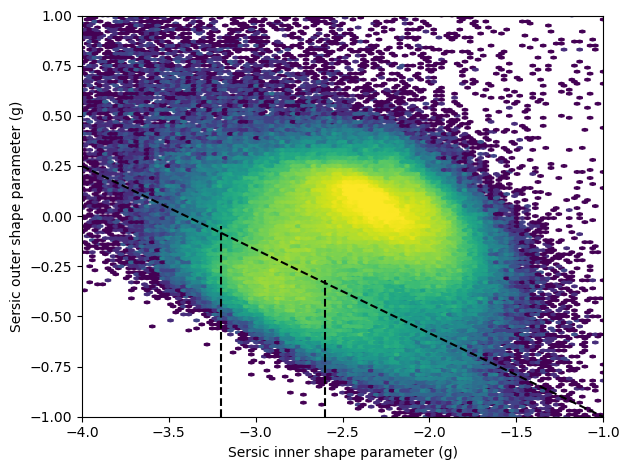

In [96]:
plt.figure(tight_layout=True)

plt.hexbin(SGA2025['COG_LNALPHA1_G'][~elliptical_25], SGA2025['COG_LNALPHA2_G'][~elliptical_25], 
           mincnt=1, 
           vmin=1, 
           vmax=250, 
           gridsize=(100,100), 
           extent=(-4, -1, -1, 1), 
           bins='log')

# plt.plot(SGA2025['COG_LNALPHA1_G'][elliptical_25], SGA2025['COG_LNALPHA2_G'][elliptical_25], '.', alpha=0.01, c='tab:red')

plt.plot([-4, -1], [0.25, -1], 'k--')
plt.vlines([-2.6, -3.2], -1, [-0.32, -0.05], colors='k', linestyles='dashed')

plt.xlim(-4,-1)
plt.ylim(-1,1)

plt.xlabel('Sersic inner shape parameter (g)')
plt.ylabel('Sersic outer shape parameter (g)');

In [94]:
alpha1 = (SGA2025['COG_LNALPHA1_G'] > -3.21) & (SGA2025['COG_LNALPHA1_G'] < -3.19)
alpha2 = (SGA2025['COG_LNALPHA2_G'] > -0.26) & (SGA2025['COG_LNALPHA2_G'] < -0.24)

SGA2025['SGAID', 'RA', 'DEC'][alpha1 & alpha2]

SGAID,RA,DEC
int64,float64,float64
4389202,158.5711177522132,10.803774841578688
4627102,169.14695658246802,4.414197237059233
4576500,165.94966982126877,-72.34359738390623
4143191,178.55896569509812,-41.47216314169107
4137100,184.8984728809315,-41.614367778268885
4115649,106.93356507650839,-62.12265551973547
4132834,156.29684465878273,-26.58420963564747
4167139,223.33676196689117,-41.978986189776414
4165611,213.07975372225448,-31.72438782697902


In [97]:
sersic_cut = SGA2025['COG_LNALPHA2_G'] < (-(1.25/3)*SGA2025['COG_LNALPHA1_G'] - 1.4267)

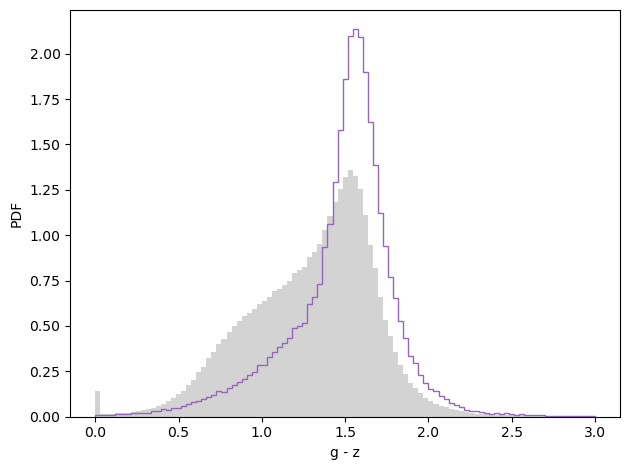

In [108]:
plt.figure(tight_layout=True)

plt.hist(SGA2025['g-z'], #SGA2025['g-z'][sersic_cut]], 
         bins=np.linspace(0,3,100), 
         density=True, 
         color='lightgray',
         # histtype='barstacked'
        )
plt.hist(SGA2025['g-z'][sersic_cut], bins=np.linspace(0,3,100), density=True, color='tab:purple', histtype='step')

plt.xlabel('g - z')
plt.ylabel('PDF');

In [109]:
SGA2025['RA', 'DEC'][sersic_cut & (SGA2025['g-z'] > 1.4)]

RA,DEC
float64,float64
198.69017283270603,-73.3970448996395
178.08157908648937,-72.49534080276509
223.17240005468892,-73.69739372339248
204.27133368079873,-74.8334956981172
212.74440548589988,-47.78103592525399
126.72259460408601,-61.718866867677264
143.38451601751328,-71.81169436283956
144.5442704701197,-37.218616158334854
114.9187494759168,-51.35754142660558


# NEW morphological classifications

In [2]:
# The BRIGHT footprint is a superset of the DARK footprint, so we just need to look at those galaxies which will be in BRIGHT

SGA2025_in_1b = Table.read('target_files/SGA2025_in_1b_bright.fits')

In [4]:
new_ssl_morphs = Table.read('/global/cfs/cdirs/desicollab/users/qshimp/morph_catalogs/SGA_2025_beta.csv', 
                            include_names=['SGAID', 'Morphology'])

new_ssl_morphs[:5]

SGAID,Morphology
int64,str10
663,Irregular
1462,Spiral
1526,Irregular
1578,Irregular
1669,Irregular


In [6]:
SGA2025_in_1b_morphs = join(SGA2025_in_1b, new_ssl_morphs, keys='SGAID', join_type='left')

In [13]:
SGA2025_in_1b_morphs['SGAID', 'RA', 'DEC', 'Morphology', 'GROUP_MULT', 'GROUP_PRIMARY'][SGA2025_in_1b_morphs['Morphology'] == 'Elliptical']

SGAID,RA,DEC,Morphology,GROUP_MULT,GROUP_PRIMARY
int64,float64,float64,str10,int16,bool
110,6.637492481864109,-22.640680604584915,Elliptical,2,True
1531,162.54067964474297,-21.25682779384567,Elliptical,1,True
2265,193.35839587581762,-21.72443363939428,Elliptical,1,True
2299,195.2561295885701,-30.719190713625082,Elliptical,1,True
2350,199.9075847873626,-23.786669861440878,Elliptical,1,True
2597,228.041990811156,-23.96682940425211,Elliptical,1,True
2610,230.1378053551452,-22.76594016040573,Elliptical,1,True
3032,301.649046920344,-25.281349182248043,Elliptical,1,True
3628,3.4067238255987964,-24.186226682430366,Elliptical,1,True


Bah.  Some of these "ellipticals" that are in groups of 1 are not actually elliptical galaxies.  So we won't be able to use this to help reduce the TFT and/or KLT target lists.